#TASK 0

In [138]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler

In [139]:
# %% Carregamento dos Dados (Ajuste Final para vetores Y)

# 1. Carregamento dos X (Mantemos o mais robusto)
solTestX = pd.read_csv('solTestX.txt', sep=r'\s+', engine='python')
solTrainX = pd.read_csv('solTrainX.txt', sep=r'\s+', engine='python')

# 2. Carregamento do Y como DUAS COLUNAS
# Lógica: O arquivo contém (Índice Tabulado | Valor Y). 
# sep=r'\s+' e engine='python' são necessários para lidar com a tabulação/espaço entre as duas colunas.
# header=None: essencial.
# names=['Index', 'Solubility']: Nomes explícitos para as duas colunas.
solTestY_raw = pd.read_csv('solTestY.txt', sep=r'\s+', engine='python', header=None, names=['Index', 'Solubility'], quoting=3, skiprows=1)
solTrainY_raw = pd.read_csv('solTrainY.txt', sep=r'\s+', engine='python', header=None, names=['Index', 'Solubility'], quoting=3, skiprows=1)


# 3. Limpeza, Conversão e Extração da Coluna Y
# O valor de solubilidade é a SEGUNDA coluna. Precisamos extrair e garantir que ela seja float.

# Extrai apenas a coluna de solubilidade do DataFrame temporário.
solTestY = solTestY_raw[['Solubility']].copy()
solTrainY = solTrainY_raw[['Solubility']].copy()

# O .astype(str).str.strip() é mantido por segurança, mas agora só está limpando a coluna correta.
solTestY['Solubility'] = solTestY['Solubility'].astype(str).str.strip().astype(float)
solTrainY['Solubility'] = solTrainY['Solubility'].astype(str).str.strip().astype(float)

print("Carregamento de todos os arquivos de dados concluído com sucesso.")

Carregamento de todos os arquivos de dados concluído com sucesso.


In [140]:
solTestX.shape, solTrainX.shape, solTestY.shape, solTrainY.shape

((316, 228), (951, 228), (316, 1), (951, 1))

In [141]:
 #, solTrainX.columns#, solTestY.head, solTrainY.head
solTrainY.columns = ['Solubility']

In [142]:
# print("--- solTrainX Head ---")
# print(solTrainX.head())
# print("\n--- solTrainX Shape ---")
# print(solTrainX.shape)

In [143]:
skew(solTrainY['Solubility'])

np.float64(-0.670373169681412)

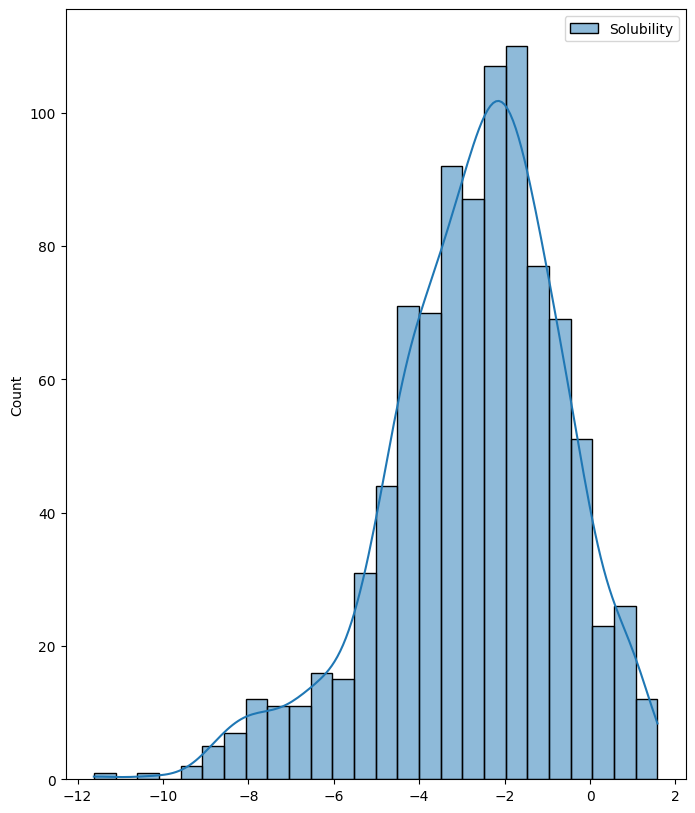

(Solubility   -11.62
 dtype: float64,
 Solubility    1.58
 dtype: float64)

In [144]:
plt.figure(figsize=(8,10))
sns.histplot(solTrainY, kde=True)
plt.show()
solTrainY.min(), solTrainY.max()

In [145]:
continuous_var = [name for name in solTrainX.columns if "FP" not in name]
continuous_var
continuous_skew = solTrainX[continuous_var].apply(lambda x: skew(x.dropna())) 
top_skew = continuous_skew[continuous_skew > 1.0].sort_values(ascending=False).head(5)
top_skew

"NumSulfer"            3.841531
"HydrophilicFactor"    3.403785
"NumChlorine"          3.177938
"NumHalogen"           2.691486
"NumOxygen"            1.771690
dtype: float64

In [146]:
x_transformed = solTrainX.copy()

transformer_yj = PowerTransformer(method='yeo-johnson')
x_continuous_transformed = transformer_yj.fit_transform(solTrainX[continuous_var])

x_continuous_transformed_df = pd.DataFrame(x_continuous_transformed, columns=continuous_var, index=solTrainX.index)
x_transformed[continuous_var] = x_continuous_transformed_df

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_transformed)
solTrainX_final = pd.DataFrame(x_scaled, columns=solTrainX.columns, index=solTrainX.index)

Text(0.5, 1.0, 'Top Skew transformado')

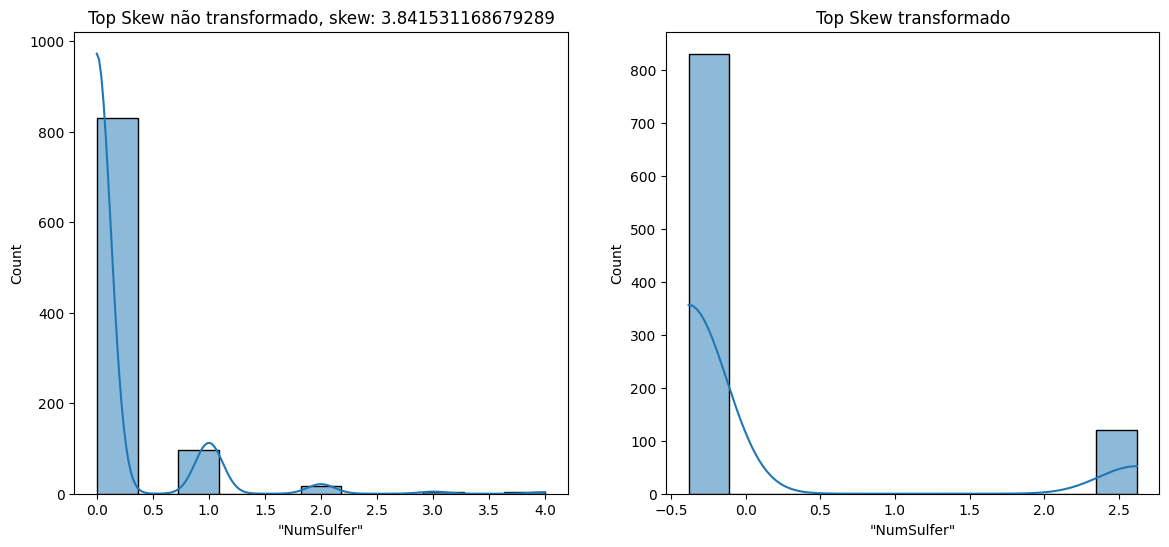

In [147]:
plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
sns.histplot(solTrainX[top_skew.index[0]], kde=True)
plt.title(f'Top Skew não transformado, skew: {continuous_skew[top_skew.index[0]]}')

plt.subplot(1,2,2)
sns.histplot(solTrainX_final[top_skew.index[0]], kde=True)
plt.title('Top Skew transformado')

In [148]:
#Pre-processamento do conjunto de teste 
x_test_transformed = solTestX.copy()
x_test_continuous_transformed = transformer_yj.transform(solTestX[continuous_var])

x_test_continuous_transformed_df = pd.DataFrame(x_test_continuous_transformed, columns=continuous_var, index=solTestX.index)
x_test_transformed[continuous_var] = x_test_continuous_transformed_df

x_test_scaled = scaler.transform(x_test_transformed)
solTestX_final = pd.DataFrame(x_test_scaled, columns=solTestX.columns, index=solTestX.index)

In [149]:
correlation_matrix = solTrainX_final.corr()
np.fill_diagonal(correlation_matrix.values, np.nan)
max_corr = correlation_matrix.abs().max().max()

In [150]:
predictor_result_correlation = solTrainX_final.corrwith(solTrainY['Solubility']).abs().sort_values(ascending=False)
print(f'preditores mais correlacionados com resultado: {predictor_result_correlation.head(5)}')

preditores mais correlacionados com resultado: "FP001"   NaN
"FP002"   NaN
"FP003"   NaN
"FP004"   NaN
"FP005"   NaN
dtype: float64


#TASK 01

#T1 a)

In [151]:
x_train = solTrainX_final.to_numpy() 
y_train = solTrainY['Solubility'].values.ravel() #
 
x_matrix_train_manual = np.insert(x_train, 0, 1, axis=1)
# CRÍTICO: Para a Equação Normal, Y precisa ser 2D. Convertemos temporariamente.
Y_train_2d = y_train.reshape(-1, 1)

xt_x = x_matrix_train_manual.T @ x_matrix_train_manual
xt_x_inv = np.linalg.inv(xt_x)
xt_x_inv_xt = xt_x_inv @ x_matrix_train_manual.T
bethas = xt_x_inv_xt @ Y_train_2d

x_matrix_train = x_train

In [152]:
x_test = solTestX_final.to_numpy()
y_test = solTestY['Solubility'].values.ravel()

x_matrix_test = np.insert(x_test, 0, 1, axis=1)

y_prediction = x_matrix_test @ bethas

In [153]:
from sklearn.metrics import mean_squared_error, r2_score
rmse_ols = np.sqrt(mean_squared_error(y_test, y_prediction))
r2_ols = r2_score(y_test, y_prediction)
rmse_ols, r2_ols

(np.float64(0.7429783847448056), 0.8718140342881492)

#T1 b)

In [154]:
from sklearn.linear_model import LinearRegression

ols_model = LinearRegression(fit_intercept=True)
ols_model.fit(x_matrix_train, y_train)
ols_model_prediction = ols_model.predict(x_test)


In [155]:
rmse_ols_model = np.sqrt(mean_squared_error(y_test, ols_model_prediction))
r2_ols_model = r2_score(y_test, ols_model_prediction)
rmse_ols_model, r2_ols_model

(np.float64(0.7429783841125779), 0.8718140345063056)

In [156]:
equality_percent = rmse_ols_model * 100 /rmse_ols
equality_percent2 = r2_ols * 100 / r2_ols_model
equality_percent, equality_percent2

(np.float64(99.99999991490631), 99.99999997497673)

In [157]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=10, shuffle = True, random_state=42)

rmse_scores_cv = []
r2_scores_cv = []

for train_index, validation_index in kf.split(x_matrix_train):

    x_train_fold, x_validation_fold = x_matrix_train[train_index], x_matrix_train[validation_index]
    y_train_fold, y_validation_fold = y_train[train_index], y_train[validation_index]

    model_fold = LinearRegression(fit_intercept=True)
    model_fold.fit(x_train_fold, y_train_fold)
    model_fold_prediction = model_fold.predict(x_validation_fold)

    rmse_scores_cv.append(np.sqrt(mean_squared_error(y_validation_fold, model_fold_prediction)))
    r2_scores_cv.append(r2_score(y_validation_fold, model_fold_prediction))

rmse_scores_cv_mean = np.mean(rmse_scores_cv)
r2_scores_cv_mean = np.mean(r2_scores_cv)    

rmse_scores_cv_mean, r2_scores_cv_mean
    

(np.float64(0.707117746062925), np.float64(0.8748903079444392))

In [158]:
from sklearn.model_selection import cross_val_score

rmse_cv_builtin = -cross_val_score(
    LinearRegression(fit_intercept=True),
    x_matrix_train,
    y_train,
    cv=kf,
    scoring='neg_mean_squared_error'
)
rmse_cv_builtin = np.sqrt(rmse_cv_builtin).mean()

r2_cv_builtin = cross_val_score(
    LinearRegression(fit_intercept=True),
    x_matrix_train,
    y_train,
    cv=kf,
    scoring='r2'
).mean()

rmse_cv_builtin, r2_cv_builtin

(np.float64(0.707117746062925), np.float64(0.8748903079444392))

In [159]:
np.all(x_matrix_train[:, 0] == 1)

np.False_